### Exploratory Data Analysis

In [2]:
# Installing the required python packages
pip install matplotlib numpy seaborn scipy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.5 MB 7.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 7.2 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 7.2 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 7.2 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 7.2 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.6 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.3 MB 7.8 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/37.3 MB 7.5 MB/s eta 0:00:05
   ----- ---------------------------------- 4.7/37.3 MB 7.4 MB/s eta 0:00:05
   ------ ---------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing the required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
import seaborn as sns
import scipy as sp
import sqlite3

In [3]:
pd.options.display.float_format = '{:.2f}'.format

### Loading data from SQLite3 to Pandas dataframe

In [4]:
# database file path
db_path = "D:/data-analyst-skill-gap/db/jobs.db"
# establish connection to database
conn = sqlite3.connect(db_path)

In [5]:
# loading the jobs table from sqlite3 database to job_df dataframe
query = """ SELECT * FROM jobs; """
job_df = pd.read_sql_query(query,conn)
job_df.head()

,job_id,title,company,location,country,category,salary_min,salary_max,salary_is_predicted,contract_time,created,num_skills,avg_salary
0,5808180305,Data Analyst Trainee,ITOL Recruit,UK,United Kingdom,IT Jobs,30000.00,50000.00,0,full_time,2026-07-20 16:02:13+00:00,0,40000.00
1,5829131501,Data Analyst,MCS Group,"Banbridge, County Down",United Kingdom,IT Jobs,30000.00,30000.00,0,Unknown,2026-08-05 15:10:55+00:00,0,30000.00
2,5822628736,Data Analyst,HAYS Specialist Recruitment,"Belfast, Northern Ireland",United Kingdom,IT Jobs,40000.00,40000.00,0,Unknown,2026-07-31 20:30:56+00:00,0,40000.00
3,5823507727,Data Analyst,Ofcom,"Belfast, Northern Ireland",United Kingdom,IT Jobs,26645.01,26645.01,1,part_time,2026-08-01 08:33:20+00:00,0,26645.01
4,5832274608,Data Analyst,Workshop Recruitment,"Portsmouth, Hampshire",United Kingdom,IT Jobs,32000.00,40000.00,0,full_time,2026-08-07 19:00:11+00:00,1,36000.00


In [6]:
# loading the job_skills table from sqlite3 database to job_skills_df dataframe
query = """ SELECT * FROM job_skills; """
job_skills_df = pd.read_sql_query(query, conn)
job_skills_df.head()

,job_id,skill
0,5832274608,Power BI
1,5807302172,ETL
2,5829585484,Excel
3,5761450305,R
4,5829136347,SQL


### Data Inspection

In [7]:
# Check the data types, column names, and missing values in the job DataFrame
job_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               450 non-null    int64  
 1   title                450 non-null    str    
 2   company              450 non-null    str    
 3   location             450 non-null    str    
 4   country              450 non-null    str    
 5   category             450 non-null    str    
 6   salary_min           341 non-null    float64
 7   salary_max           341 non-null    float64
 8   salary_is_predicted  450 non-null    int64  
 9   contract_time        450 non-null    str    
 10  created              450 non-null    str    
 11  num_skills           450 non-null    int64  
 12  avg_salary           341 non-null    float64
dtypes: float64(3), int64(3), str(7)
memory usage: 45.8 KB


In [8]:
# Check the data types, column names, and missing values in the job_skills DataFrame
job_skills_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   job_id  275 non-null    int64
 1   skill   275 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.4 KB


### Type Conversion

In [9]:
# Convert 'created' column to datetime format and verify the new data type
job_df['created'] = pd.to_datetime(job_df['created'])
print(job_df['created'].dtypes)

datetime64[us, UTC]


### Missing  Value Analysis

In [10]:
# Count the number of missing values in each column
job_df.isnull().sum()

job_id                   0
title                    0
company                  0
location                 0
country                  0
category                 0
salary_min             109
salary_max             109
salary_is_predicted      0
contract_time            0
created                  0
num_skills               0
avg_salary             109
dtype: int64

In [11]:
# Create a True/False column: True means the salary is missing
job_df['salary_missing'] = job_df['avg_salary'].isnull()
# Calculate the percentage of missing salaries for each country
job_df.groupby('country')['salary_missing'].agg('mean')*100

country
India            72.67
United Kingdom    0.00
United States     0.00
Name: salary_missing, dtype: float64

In [12]:
# Group data by country and category to see where salary transparency varies across the globe
result = job_df.groupby(['country','category'])['salary_missing'].agg(['count','mean'])
# Convert the missing ratio to a percentage (e.g., 0.45 becomes 45% missing data)
result['mean'] = result['mean']*100
# Reveal the final table to pinpoint exactly which industries and regions hide salaries the most
result

count   mean
country        category                                      
India          Accounting & Finance Jobs             3 100.00
               Admin Jobs                            1   0.00
               HR & Recruitment Jobs                 1 100.00
               Healthcare & Nursing Jobs             1 100.00
               IT Jobs                             141  71.63
               Manufacturing Jobs                    1 100.00
               Sales Jobs                            1 100.00
               Scientific & QA Jobs                  1 100.00
United Kingdom Accounting & Finance Jobs            10   0.00
               Admin Jobs                            4   0.00
               Consultancy Jobs                      1   0.00
               Graduate Jobs                         3   0.00
               IT Jobs                             127   0.00
               PR, Advertising & Marketing Jobs      2   0.00
               Part time Jobs                        1   0.00
               Scientific & QA Jobs                  2   0.00
United States  Accounting & Finance Jobs             8   0.00
               Admin Jobs                            1   0.00
               Engineering Jobs                      3   0.00
               HR & Recruitment Jobs                 4   0.00
               IT Jobs                             133   0.00
               Scientific & QA Jobs                  1   0.00

### Descriptive Stats and Distributions

In [13]:
descriptive_stats = job_df.groupby(['country'])['avg_salary'].describe().round(2)
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
India,41.00,767414.63,571685.22,22500.00,400000.00,700000.00,1032500.00,3250000.00
United Kingdom,150.00,52442.37,23932.89,15600.00,40000.00,46000.00,61371.96,219440.00
United States,150.00,96513.46,30355.26,50206.81,72767.69,90608.03,117258.81,208397.75


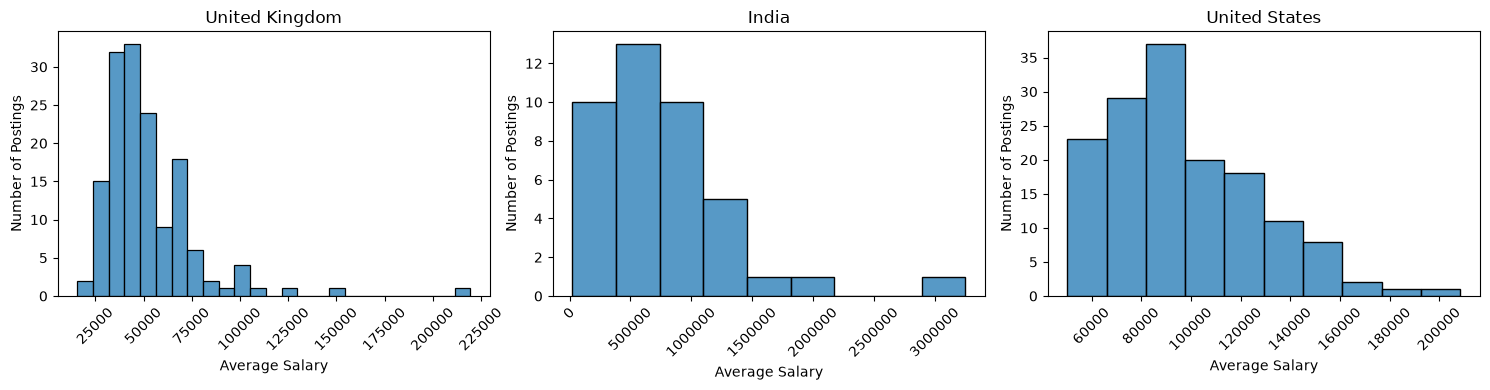

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, country in enumerate(job_df['country'].unique()):
    data = job_df[job_df['country'] == country]

    sns.histplot(data['avg_salary'], ax=axes[i],)
    axes[i].set_title(country)
    axes[i].set_xlabel('Average Salary')
    axes[i].set_ylabel('Number of Postings')
    axes[i].ticklabel_format(style='plain', axis='x')  # disables scientific notation
    axes[i].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()

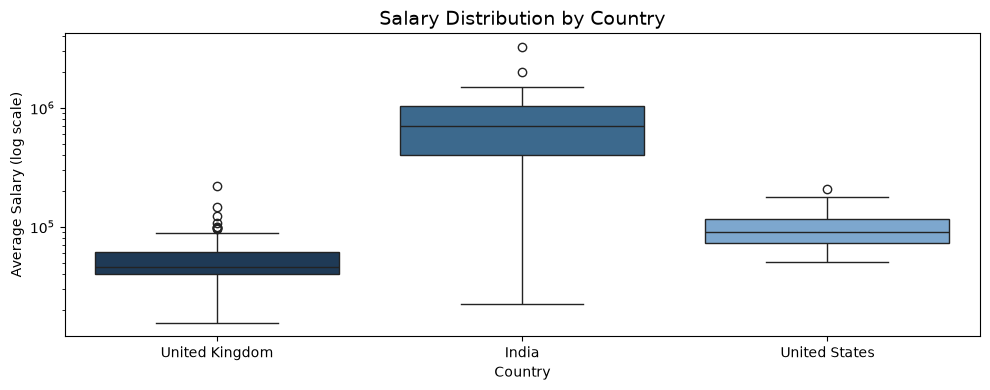

In [15]:
# Plot of salaries across different countries on their original currency scale using a log-scale box plot
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=job_df,
    x='country',
    y='avg_salary',
    hue='country',
    palette = ['#163A5F', '#2F6B9A', '#6FA8DC'],
    legend=False
)
plt.yscale('log')
plt.title('Salary Distribution by Country', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Average Salary (log scale)')

plt.tight_layout()
plt.show()

In [16]:
# Convert average salaries to USD based on the employee's country
# Currency conversion rates as of Aug 20, 2026 (static snapshot, not live-updated)
INR_TO_USD = 0.0105
GBP_TO_USD = 1.3610

job_df['avg_salary_usd'] = np.where(job_df['country'] == 'India', job_df['avg_salary'] * INR_TO_USD,
                                    np.where(job_df['country'] == 'United Kingdom', job_df['avg_salary'] * GBP_TO_USD,
                                    job_df['avg_salary']))  # US already in USD

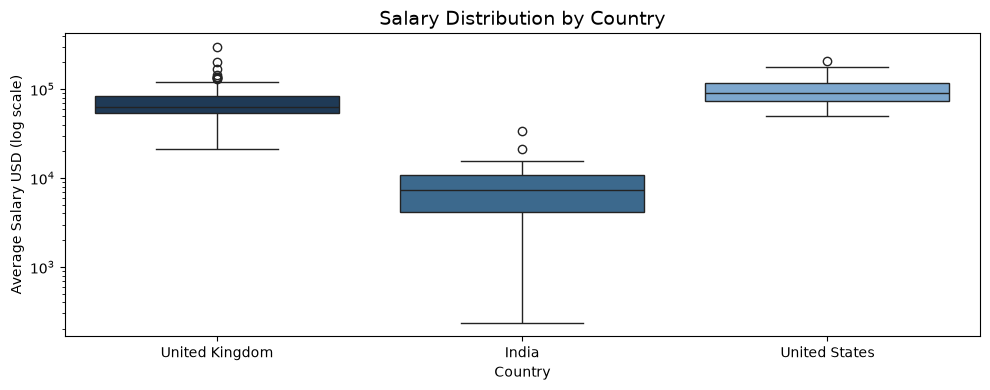

In [17]:
# Plot of salaries across different countries on a common currency scale of USD using a log-scale box plot
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=job_df,
    x='country',
    y='avg_salary_usd',
    hue='country',
    palette = ['#163A5F', '#2F6B9A', '#6FA8DC'],
    legend=False
)
plt.yscale('log')
plt.title('Salary Distribution by Country', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Average Salary USD (log scale)')

plt.tight_layout()
plt.show()

In [18]:
job_skills_df.head()

,job_id,skill
0,5832274608,Power BI
1,5807302172,ETL
2,5829585484,Excel
3,5761450305,R
4,5829136347,SQL


In [19]:
# Create a skill matrix:
# Rows = job postings (job_id)
# Columns = skills
# Values = number of times each skill appears in a job posting
skill_matrix = pd.crosstab(index = job_skills_df['job_id'],columns = job_skills_df['skill'])
skill_matrix

skill,AWS,Alteryx,Azure,Big Query,ETL,Excel,Looker,Machine Learning,Power BI,Python,R,SAS,SQL,Spark,Statistics,Tableau,VBA
job_id,,,,,,,,,,,,,,,,,
1993882092,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2177266370,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
2247134476,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
2403881225,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2449398766,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832798167,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0
5832798180,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0
5832798181,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0


In [42]:
# Calculate how often skills appear together across the same job postings
co_occurrence_matrix = skill_matrix.T.dot(skill_matrix)
# Convert DataFrame to NumPy array
co_occurrence_array = co_occurrence_matrix.to_numpy(copy=True)  # guaranteed writable copy
# Set diagonal to 0
np.fill_diagonal(co_occurrence_array, 0)

# put it back into a labeled DataFrame so row/column names (skill names) are preserved
co_occurrence_clean = pd.DataFrame(co_occurrence_array, 
                                     index=co_occurrence_matrix.index, 
                                     columns=co_occurrence_matrix.columns)

<Axes: xlabel='skill', ylabel='skill'>

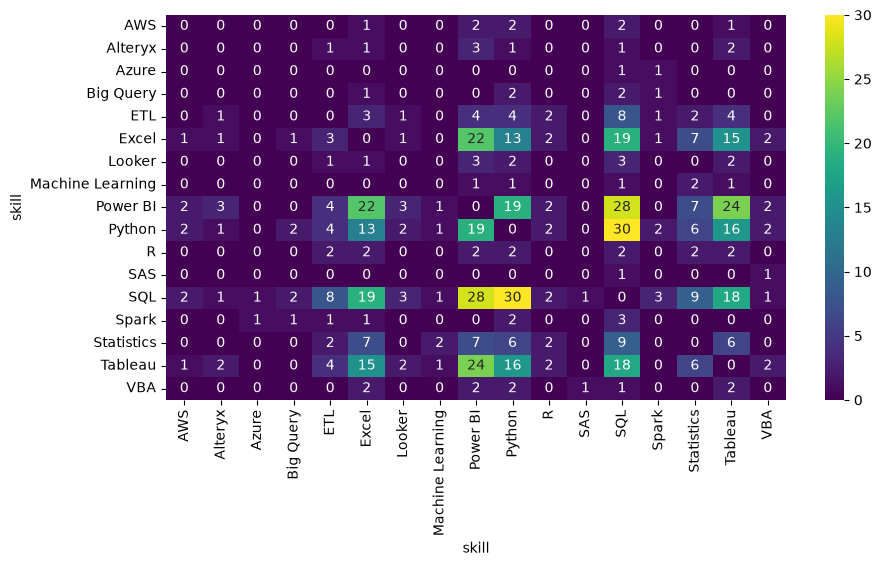

In [57]:
# plottinf heatmap for th skill_ocurrence matrix
plt.figure(figsize=(10,5))
sns.heatmap(data = co_occurrence_clean, annot= True, fmt='d', cmap = 'viridis')

In [62]:
job_df.to_csv('D:\\data-analyst-skill-gap\\dashboard\\jobs.csv',index = False)
job_skills_df.to_csv('D:\\data-analyst-skill-gap\\dashboard\\jobs_skills.csv', index = False)